<a href="https://colab.research.google.com/github/meg190/aplicadas-II-colabs/blob/main/EA1_taller_python_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

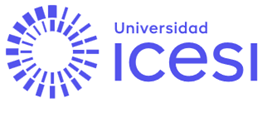


FACULTAD BARBERI DE INGENIERIAS, DISEÑO Y CIENCIAS APLICADAS.

DEPARTAMENTO DE CIENCIAS FISICAS Y APLICADAS.

**Profesor:** Daniel Osorio

# Estadística Aplicada I — Taller 100% Python (Notebook base)
### Pregrado | Clase práctica: del cero a un mini-análisis de datos

**Objetivo de hoy:** cargar datos, explorar, transformar variables, resumir con estadística descriptiva y graficar.

> Tip: si algo falla, levanta la mano.

## 0. ¿Dónde estamos trabajando?
Puedes ejecutar este notebook en:
- **Google Colab** (recomendado en clase)
- **Jupyter Notebook / JupyterLab**
- **VSCode** (con extensión de Jupyter)

### Celdas
- **Markdown**: texto, fórmulas, instrucciones.
- **Código**: Python que se ejecuta.

**Atajos útiles (Colab/Jupyter):**
- Ejecutar celda: `Shift + Enter`
- Insertar celda arriba: `A`
- Insertar celda abajo: `B`
- Cambiar a Markdown: `M`
- Cambiar a Código: `Y`


In [ ]:
print("Hola mundo")

Hola mundo


In [ ]:
# Esto es un comentario
## Esto es otro comentario

# Esto no es un comentario, es un título
## Esto no es un comentario, es un subtítulo

## 0.1 Instalación rápida (solo si hace falta)

¿Por qué necesitamos instalar librerías?

Python por sí solo es un lenguaje de programación básico. Para realizar análisis estadístico y científico necesitamos herramientas especializadas. Las librerías son conjuntos de funciones pre-escritas que nos ayudan a:

1. pandas: Manipular y analizar datos (como Excel pero más poderoso)
2. numpy: Realizar cálculos matemáticos y estadísticos eficientemente
3. matplotlib: Crear gráficos y visualizaciones básicas
4. seaborn: Crear gráficos estadísticos más atractivos y profesionales
INSTALACIÓN (ejecutar en terminal o cmd): pip install pandas numpy matplotlib seaborn

O en Jupyter/Colab: !pip install pandas numpy matplotlib seaborn (estas ya estan pre-instaladas en Colab)

En Colab usualmente ya está todo instalado. Si estás en un entorno local y te falta algo, ejecuta:

```bash
pip install pandas numpy matplotlib openpyxl pyarrow
```

*(En Colab NO uses conda; en local, si tienes Anaconda, puedes usar `conda install`.)*

## 0.2 Importar librerías (lo mínimo para hoy)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Para ver tablas completas (opcional)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

print("✅ Librerías cargadas")

# Configuración para que los gráficos se vean mejor
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


✅ Librerías cargadas


## 0.3 Conceptos básicos de Python

## - Tipos de variables

In [ ]:
entero = 10
decimal = 3.14
texto = "Daniel"
booleano = True

In [ ]:
type(entero)

int

## - Listas

In [ ]:
lista = [1,2,3,4]

## - Diccionarios

In [ ]:
dic = {"edad": 30, "ciudad": "Cali"}

## - Data Frame

Lo vemos ahora

## 0.3 Numpy

In [ ]:
a = np.array([1,2,3,4])

In [ ]:
np.mean(a)
np.std(a)
np.max(a)

4

## 1. Dataset: opción A: cargar tu archivo real
### En Google Colab
1. Ejecuta la siguiente celda
2. Selecciona tu archivo (CSV o Excel)


In [ ]:
# SOLO PARA COLAB:
# Si estás en Jupyter/VScode local, puedes comentar estas líneas.
try:
    from google.colab import files
    uploaded = files.upload()  # selecciona archivo
    print("Archivos cargados:", list(uploaded.keys()))
except Exception as e:
    print("Parece que NO estás en Colab (está bien). Error/aviso:", e)


Saving Encuesta de perfil de estudiantes (2026-1).xlsx to Encuesta de perfil de estudiantes (2026-1).xlsx
Archivos cargados: ['Encuesta de perfil de estudiantes (2026-1).xlsx']


### Lectura del archivo (CSV o Excel)
- Si tu archivo es `.csv` usa `pd.read_csv`
- Si tu archivo es `.xlsx` usa `pd.read_excel`

✅ **Edita el nombre del archivo en la variable `filename`.**


In [ ]:
# CAMBIA ESTE NOMBRE por el archivo que quieres cargar o cargaste / tienes en tu carpeta
filename = 'https://raw.githubusercontent.com/profedaniel86/Clase-Bioestad-stica/refs/heads/main/Practica%20R/Practica.csv'  # ejemplo: "datos.csv" o "datos.xlsx"

df = None

if filename is None:
    print("⚠️ Define filename con el nombre de tu archivo.")
else:
    if filename.lower().endswith(".csv"):
        df = pd.read_csv(filename, sep=";")  # Cambia sep="," si tu CSV usa comas
    elif filename.lower().endswith(".xlsx") or filename.lower().endswith(".xls"):
        df = pd.read_excel(filename)
    elif filename.lower().endswith(".parquet"):
        df = pd.read_parquet(filename)
    else:
        raise ValueError("Tipo de archivo no soportado en este notebook base.")

    print("✅ Dataset cargado. Filas/Columnas:", df.shape)


✅ Dataset cargado. Filas/Columnas: (189, 11)


Lea el archivo "Encuesta de perfil de estudiantes (2026-1).xlsx" y coloque el nombre al Dataframe "Datos_estudiantes"

## Dataset: opción B (backup): generar datos sintéticos
Si no tienes archivo a mano, generamos un dataset realista para practicar.


In [ ]:
# Puedes ejecutar esta celda si df está vacío (None) o si quieres practicar con datos sintéticos.

rng = np.random.default_rng(42)
n = 800

edad = rng.integers(17, 70, size=n)
sexo = rng.choice(["F", "M"], size=n, p=[0.52, 0.48])
programa = rng.choice(["Ing Sistemas", "Industrial", "Civil", "Diseño"], size=n, p=[0.30, 0.25, 0.25, 0.20])
semestre = rng.integers(1, 11, size=n)

# variable continua con ruido
horas_estudio = np.clip(rng.normal(8, 4, size=n), 0, 30)

# Nota influenciada por horas de estudio y semestre, con ruido
nota = 2.5 + 0.05*horas_estudio + 0.03*semestre + rng.normal(0, 0.6, size=n)
nota = np.clip(nota, 0, 5)

# Ingreso mensual (ejemplo socioeconómico)
ingreso = np.exp(rng.normal(14.2, 0.4, size=n))  # distribución lognormal
ingreso = np.round(ingreso / 1000) * 1000  # redondeo

# Missing values simulados
ingreso = ingreso.astype("float")
mask_na = rng.random(n) < 0.08
ingreso[mask_na] = np.nan

df_sint = pd.DataFrame({
    "edad": edad,
    "sexo": sexo,
    "programa": programa,
    "semestre": semestre,
    "horas_estudio": np.round(horas_estudio, 1),
    "nota": np.round(nota, 2),
    "ingreso_mensual": ingreso,
})

if df is None:
    df = df_sint.copy()
    print("✅ Usando dataset sintético:", df.shape)
else:
    print("ℹ️ df ya existe. Si quieres reemplazarlo por sintético, ejecuta: df = df_sint.copy()")

df.head()


ℹ️ df ya existe. Si quieres reemplazarlo por sintético, ejecuta: df = df_sint.copy()


,id,Bajo_peso,Edad,Peso_madre,Raza,Fumar,TPP,Ant_HTA,Irrit_uterina,Visitas_md,peso_nacer
0,1,0,25,120,white,0,0,0,0,2,3983
1,2,0,25,241,black,0,0,1,0,0,3790
2,3,0,32,132,white,0,0,0,0,4,3080
3,4,0,21,124,other,0,0,0,0,0,2622
4,5,1,24,132,other,0,0,1,0,0,1729


In [ ]:
df = df_sint.copy()

## 2. Primera exploración: ¿qué contiene el dataset?

In [ ]:
# Vista rápida
df.head()


,edad,sexo,programa,semestre,horas_estudio,nota,ingreso_mensual
0,21,F,Civil,4,10.6,3.31,1098000.0
1,58,M,Civil,9,10.5,2.75,3812000.0
2,51,M,Diseño,1,7.9,3.17,1430000.0
3,40,F,Civil,5,8.8,3.01,1248000.0
4,39,M,Ing Sistemas,9,3.3,2.57,1484000.0


In [ ]:
# Tamaño
df.shape


(800, 7)

In [ ]:
# Nombres de columnas
df.columns


Index(['edad', 'sexo', 'programa', 'semestre', 'horas_estudio', 'nota', 'ingreso_mensual'], dtype='object')

In [ ]:
# Tipos y valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   edad             800 non-null    int64  
 1   sexo             800 non-null    object 
 2   programa         800 non-null    object 
 3   semestre         800 non-null    int64  
 4   horas_estudio    800 non-null    float64
 5   nota             800 non-null    float64
 6   ingreso_mensual  738 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 43.9+ KB


## 3. Tipos de variables

Marca cada columna como:
- **Cualitativa nominal** (categorías sin orden)
- **Cualitativa ordinal** (categorías con orden)
- **Cuantitativa discreta**
- **Cuantitativa continua**

👉 Ejemplo: `sexo` nominal, `semestre` discreta/ordinal, `nota` continua.


In [ ]:
# Lista de columnas por tipo (edita según tu dataset)
cualitativas = ["sexo", "programa"]  # nominal u ordinal
cuantitativas = ["edad", "semestre", "horas_estudio", "nota", "ingreso_mensual"]

# Validación simple
print("Cualitativas:", [c for c in cualitativas if c in df.columns])
print("Cuantitativas:", [c for c in cuantitativas if c in df.columns])


Cualitativas: ['sexo', 'programa']
Cuantitativas: ['edad', 'semestre', 'horas_estudio', 'nota', 'ingreso_mensual']


## 4. Selección y filtrado (básico)

In [ ]:
# Seleccionar una columna (Serie)
df["edad"].head()


0    21
1    58
2    51
3    40
4    39
Name: edad, dtype: int64

In [ ]:
# Seleccionar varias columnas (DataFrame)
df[["edad", "nota"]].head()


,edad,nota
0,21,3.31
1,58,2.75
2,51,3.17
3,40,3.01
4,39,2.57


In [ ]:
# Filtrar filas
df[df["edad"] >= 30].head()


,edad,sexo,programa,semestre,horas_estudio,nota,ingreso_mensual
1,58,M,Civil,9,10.5,2.75,3812000.0
2,51,M,Diseño,1,7.9,3.17,1430000.0
3,40,F,Civil,5,8.8,3.01,1248000.0
4,39,M,Ing Sistemas,9,3.3,2.57,1484000.0
5,62,M,Ing Sistemas,10,0.0,2.33,659000.0


In [ ]:
# Filtrar por varias condiciones
df[(df["edad"] >= 30) & (df["nota"] >= 3.5)].head()


,edad,sexo,programa,semestre,horas_estudio,nota,ingreso_mensual
13,57,M,Industrial,5,9.9,3.55,1224000.0
26,38,F,Industrial,3,10.0,3.61,1665000.0
34,64,F,Ing Sistemas,5,10.7,3.60,1064000.0
48,52,F,Diseño,4,5.4,3.51,1133000.0
53,41,F,Civil,9,5.2,3.69,3597000.0


## 5. Limpieza mínima: nulos y valores sospechosos

In [ ]:
# Conteo de nulos por columna
df.isna().sum().sort_values(ascending=False).head(20)


ingreso_mensual    62
edad                0
sexo                0
programa            0
semestre            0
horas_estudio       0
nota                0
dtype: int64

In [ ]:
# Ejemplo 1: rellenar nulos de una variable numérica con mediana (si aplica)
col = "ingreso_mensual"
if col in df.columns:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f"✅ Nulos en {col} rellenados con mediana = {med:,.0f}")
else:
    print("ℹ️ La columna no existe en este dataset.")


✅ Nulos en ingreso_mensual rellenados con mediana = 1,465,500


## 6. Transformaciones de variables

In [ ]:
# Variable derivada: categoría de edad (bins)
if "edad" in df.columns:
    df["grupo_edad"] = pd.cut(df["edad"], bins=[0, 18, 30, 45, 60, 120],
                              labels=["<=18", "19-30", "31-45", "46-60", "60+"])
    df[["edad", "grupo_edad"]].head()
else:
    print("ℹ️ No existe 'edad' en el dataset.")


In [ ]:
# Transformación log (útil para variables sesgadas, como ingresos)
col = "ingreso_mensual"
if col in df.columns:
    df["log_ingreso"] = np.log(df[col].clip(lower=1))
    df[[col, "log_ingreso"]].head()
else:
    print("ℹ️ La columna no existe en este dataset.")


## 7. Estadística descriptiva (numéricas)

In [ ]:
# Resumen clásico: count, mean, std, min, cuartiles, max
df.describe()


,edad,semestre,horas_estudio,nota,ingreso_mensual,log_ingreso
count,800.000000,800.000000,800.000000,800.000000,8.000000e+02,800.000000
mean,43.370000,5.263750,8.225000,3.061163,1.573742e+06,14.198141
std,15.222114,2.894764,3.982282,0.625151,6.267820e+05,0.374653
min,17.000000,1.000000,0.000000,1.190000,4.180000e+05,12.943237
25%,30.000000,3.000000,5.400000,2.627500,1.140750e+06,13.947195
50%,43.000000,5.000000,8.050000,3.080000,1.465500e+06,14.197707
75%,57.000000,8.000000,11.000000,3.460000,1.828750e+06,14.419143
max,69.000000,10.000000,20.200000,5.000000,5.435000e+06,15.508370


In [ ]:
# Medidas puntuales sobre una variable
col = "nota"
if col in df.columns:
    print("Media:", df[col].mean())
    print("Mediana:", df[col].median())
    print("Desv. estándar:", df[col].std())
    print("Q1:", df[col].quantile(0.25))
    print("Q3:", df[col].quantile(0.75))
else:
    print("ℹ️ La columna no existe en este dataset.")


Media: 3.0611625000000005
Mediana: 3.08
Desv. estándar: 0.6251514148252986
Q1: 2.6275
Q3: 3.46


## 8. Tablas de frecuencia (cualitativas)

In [ ]:
col = "programa"
if col in df.columns:
    df[col].value_counts()
else:
    print("ℹ️ La columna no existe en este dataset.")


In [ ]:
# Frecuencia relativa
col = "programa"
if col in df.columns:
    df[col].value_counts(normalize=True).round(3)
else:
    print("ℹ️ La columna no existe en este dataset.")


In [ ]:
# Tabla cruzada (dos cualitativas)
if set(["programa", "sexo"]).issubset(df.columns):
    pd.crosstab(df["programa"], df["sexo"], margins=True)
else:
    print("ℹ️ Asegúrate de tener 'programa' y 'sexo' o cambia los nombres.")


## 9. Gráficos básicos

¿POR QUÉ HACER GRÁFICOS?

Los gráficos nos ayudan a:
1. Entender los datos más rápidamente
2. Identificar patrones y tendencias
3. Comunicar resultados de forma efectiva
4. Detectar valores atípicos o anomalías


### 9.1 Barras (cualitativa)

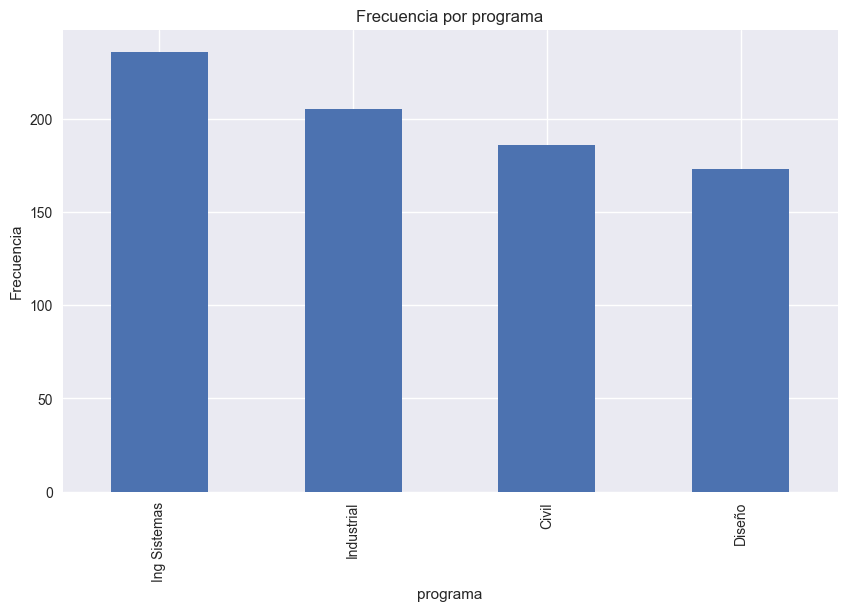

In [ ]:
col = "programa"
if col in df.columns:
    df[col].value_counts().plot(kind="bar")
    plt.title("Frecuencia por programa")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()
else:
    print("ℹ️ Cambia 'col' por una variable cualitativa de tu dataset.")


### 9.2 Torta (cualitativa)

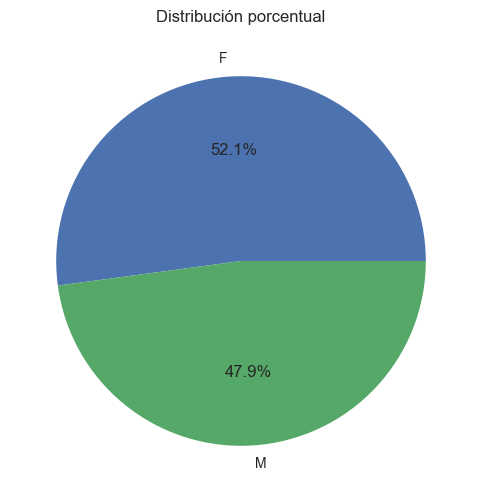

In [ ]:
col = "sexo"
if col in df.columns:
    df[col].value_counts().plot(kind="pie", autopct="%.1f%%")
    plt.title("Distribución porcentual")
    plt.ylabel("")
    plt.show()
else:
    print("ℹ️ Cambia 'col' por una variable cualitativa de tu dataset.")


### 9.3 Histograma (numérica)

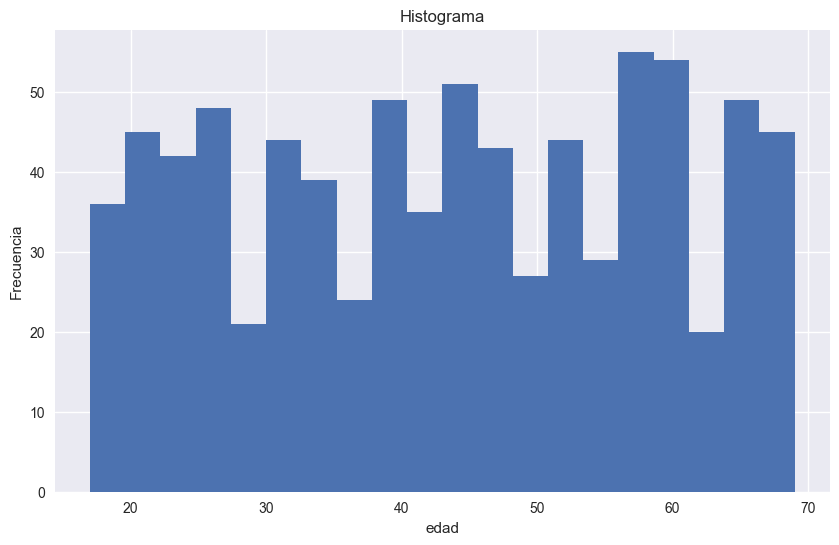

In [ ]:
col = "edad"
if col in df.columns:
    df[col].plot(kind="hist", bins=20)
    plt.title("Histograma")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()
else:
    print("ℹ️ Cambia 'col' por una variable numérica de tu dataset.")


### 9.4 Ojiva

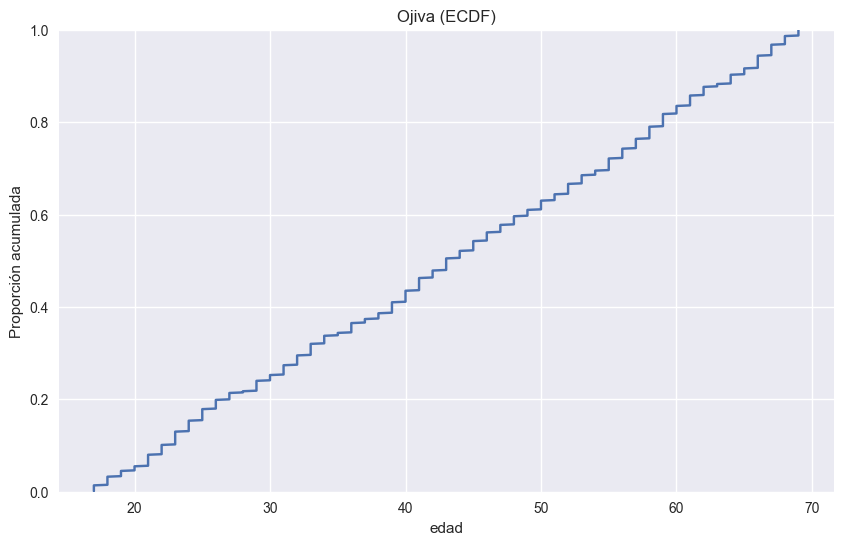

In [ ]:
# Ojiva: curva acumulada empírica
col = "edad"
if col in df.columns:
    x = np.sort(df[col].dropna().to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y)
    plt.title("Ojiva (ECDF)")
    plt.xlabel(col)
    plt.ylabel("Proporción acumulada")
    plt.ylim(0, 1)
    plt.show()
else:
    print("ℹ️ Cambia 'col' por una variable numérica de tu dataset.")


### 9.5 Boxplot (numérica)

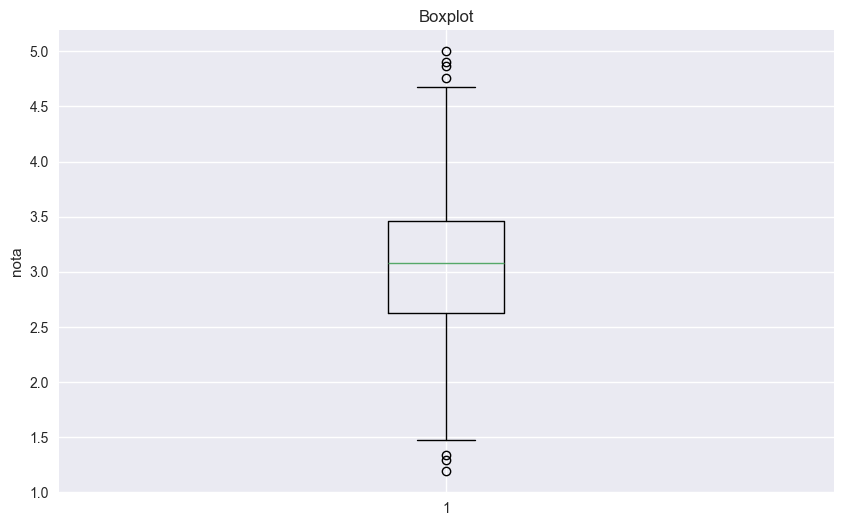

In [ ]:
col = "nota"
if col in df.columns:
    plt.boxplot(df[col].dropna())
    plt.title("Boxplot")
    plt.ylabel(col)
    plt.show()
else:
    print("ℹ️ Cambia 'col' por una variable numérica de tu dataset.")


### 9.6 Dispersión (dos numéricas)

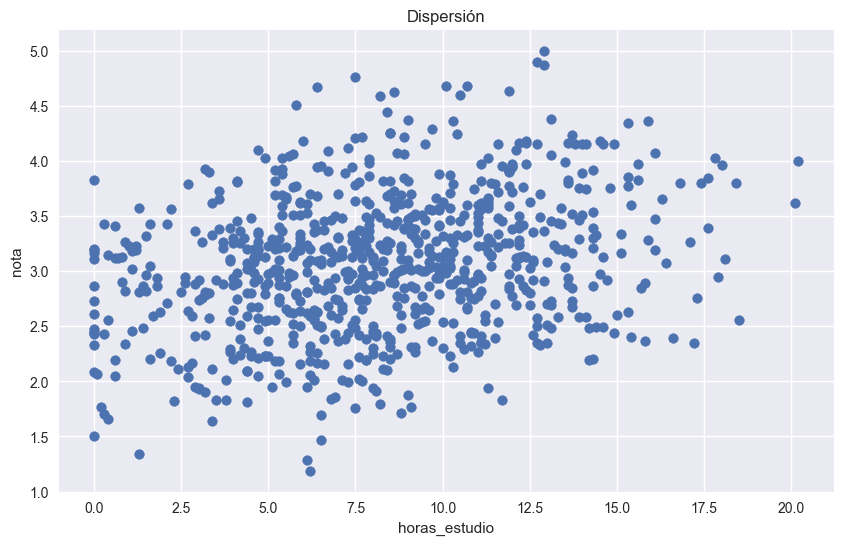

In [ ]:
xcol, ycol = "horas_estudio", "nota"
if set([xcol, ycol]).issubset(df.columns):
    plt.scatter(df[xcol], df[ycol])
    plt.title("Dispersión")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.show()
else:
    print("ℹ️ Cambia xcol/ycol por dos variables numéricas de tu dataset.")


## 10. Definición de funciones (del cero a lo útil en análisis de datos)

En Python, una **función** es una receta reutilizable.

### ¿Por qué nos sirven en Estadística Aplicada?
- Para **no repetir código**
- Para estandarizar cálculos (ej. media, percentiles, tablas)
- Para crear *mini-herramientas*: “dame una variable y te hago el gráfico / la tabla”

**Estructura básica:**
```python
def nombre_funcion(entrada1, entrada2=valor_por_defecto):
    # pasos
    return salida
```


In [ ]:
# 1) Función más simple: no recibe nada, solo imprime
def saludar():
    print("Hola, vamos con Python 😄")

saludar()


Hola, vamos con Python 😄


In [ ]:
# 2) Función con 1 entrada y un return
def cuadrado(x):
    return x**2

cuadrado(5)


25

In [ ]:
# 3) Función con varias entradas + valor por defecto
def promedio(x, y, redondear=2):
    prom = (x + y) / 2
    return round(prom, redondear)

promedio(3.1416, 2.7183)


2.93

### Mini-ejercicio (2–5 min)
1) Crea una función `rango(x)` que devuelva `max(x) - min(x)`.

### 10.5.1) Función para tabla de frecuencia (cualitativas)

In [ ]:
df["programa"].value_counts(dropna=False, normalize=True)

programa
Ing Sistemas    0.29500
Industrial      0.25625
Civil           0.23250
Diseño          0.21625
Name: proportion, dtype: float64

In [ ]:
def tabla_distribucion(df, col, ordenar=True, incluir_na=False, decimales=4):
    """
    Genera tabla de distribución de frecuencias para variables
    cualitativas o cuantitativas discretas.

    Parámetros
    ----------
    df : pandas.DataFrame
    col : str -> nombre de la columna
    ordenar : bool -> si True ordena por valores (útil en discretas)
    incluir_na : bool -> si True incluye valores NA
    decimales : int -> número de decimales para frecuencias relativas

    Retorna
    -------
    pandas.DataFrame con:
        - Frecuencia absoluta
        - Frecuencia relativa
        - Frecuencia acumulada
        - Frecuencia relativa acumulada
    """

    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el DataFrame.")

    # Frecuencia absoluta
    freq_abs = df[col].value_counts(dropna=not incluir_na)

    if ordenar:
        try:
            freq_abs = freq_abs.sort_index()
        except:
            pass  # si no puede ordenar (mezcla tipos), lo deja como está

    n = freq_abs.sum()

    # Frecuencia relativa
    freq_rel = freq_abs / n

    # Acumuladas
    freq_acum = freq_abs.cumsum()
    freq_rel_acum = freq_rel.cumsum()

    # Construcción del DataFrame final
    tabla = pd.DataFrame({
        "Frecuencia": freq_abs,
        "Frecuencia_relativa": freq_rel.round(decimales),
        "Frecuencia_acumulada": freq_acum,
        "Frecuencia_rel_acum": freq_rel_acum.round(decimales)
    })

    return tabla

In [ ]:
tabla_distribucion(df, "programa")

,Frecuencia,Frecuencia_relativa,Frecuencia_acumulada,Frecuencia_rel_acum
programa,,,,
Civil,186,0.2325,186,0.2325
Diseño,173,0.2162,359,0.4488
Industrial,205,0.2562,564,0.7050
Ing Sistemas,236,0.2950,800,1.0000


### 10.5.2) Función para histograma (numéricas)

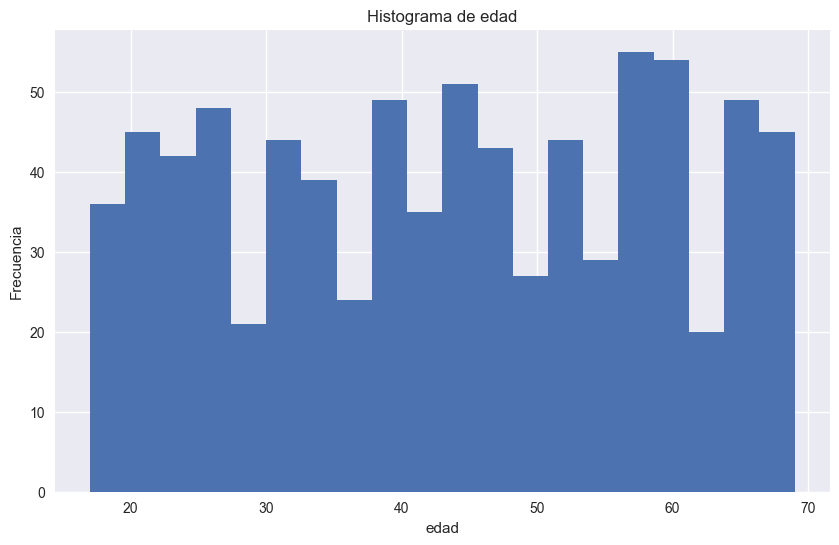

In [ ]:
def histograma(df, col, bins=20, titulo=None):
    """Grafica histograma de una columna numérica."""
    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el DataFrame.")
    x = df[col].dropna()
    plt.figure()
    plt.hist(x, bins=bins)
    plt.title(titulo if titulo else f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Ejemplo (cambia 'edad' por tu variable numérica)
if "edad" in df.columns:
    histograma(df, "edad", bins=20)
else:
    print("ℹ️ Prueba con una columna numérica de tu dataset.")


In [ ]:

def tabla_frecuencia_continua(df, col, k=10, incluir_na=False, decimales=4):
    """
    Tabla de distribución de frecuencias para variable cuantitativa continua.

    Incluye:
    - Intervalo (clase)
    - Límite inferior y superior
    - Marca de clase
    - Frecuencia simple (fi)
    - Frecuencia relativa (hi)
    - Frecuencia acumulada (Fi)
    - Frecuencia relativa acumulada (Hi)

    Parámetros
    ----------
    df : pandas.DataFrame
    col : str
    k : int (número de intervalos)
    incluir_na : bool
    decimales : int

    Retorna
    -------
    pandas.DataFrame
    """
    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el DataFrame.")

    x = df[col]
    if not incluir_na:
        x = x.dropna()
    else:
        x = x.copy()

    # Asegurar numérico
    x = pd.to_numeric(x, errors="coerce")
    x = x.dropna()  # por si hubo strings u otros

    if x.empty:
        raise ValueError(f"No hay datos numéricos válidos en '{col}'.")

    if k < 1:
        raise ValueError("k debe ser >= 1")

    # Bordes de intervalos (k bins)
    min_x = float(x.min())
    max_x = float(x.max())

    # Si todos los valores son iguales, no hay intervalos útiles
    if np.isclose(min_x, max_x):
        tabla = pd.DataFrame({
            "intervalo": [f"[{min_x}, {max_x}]"],
            "li": [min_x],
            "ls": [max_x],
            "marca_clase": [min_x],
            "fi": [len(x)],
            "hi": [1.0],
            "Fi": [len(x)],
            "Hi": [1.0],
        })
        return tabla

    edges = np.linspace(min_x, max_x, k + 1)

    # Construir intervalos
    clases = pd.cut(x, bins=edges, include_lowest=True, right=True)

    fi = clases.value_counts(sort=False)
    n = fi.sum()

    hi = (fi / n).round(decimales)
    Fi = fi.cumsum()
    Hi = (Fi / n).round(decimales)

    # Extraer límites y marca de clase
    li = np.array([iv.left for iv in fi.index], dtype=float)
    ls = np.array([iv.right for iv in fi.index], dtype=float)
    marca = ((li + ls) / 2).round(decimales)

    tabla = pd.DataFrame({
        "intervalo": [str(iv) for iv in fi.index],
        "li": li,
        "ls": ls,
        "marca_clase": marca,
        "ni": fi.values,
        "fi": hi.values,
        "Ni": Fi.values,
        "Fi": Hi.values,
    })

    return tabla

In [ ]:
tabla_frecuencia_continua(df, "edad", k=20)

,intervalo,li,ls,marca_clase,ni,fi,Ni,Fi
0,"(16.999, 19.6]",16.999,19.6,18.2995,36,0.0450,36,0.0450
1,"(19.6, 22.2]",19.600,22.2,20.9000,45,0.0562,81,0.1013
2,"(22.2, 24.8]",22.200,24.8,23.5000,42,0.0525,123,0.1538
3,"(24.8, 27.4]",24.800,27.4,26.1000,48,0.0600,171,0.2138
4,"(27.4, 30.0]",27.400,30.0,28.7000,31,0.0388,202,0.2525
5,"(30.0, 32.6]",30.000,32.6,31.3000,34,0.0425,236,0.2950
6,"(32.6, 35.2]",32.600,35.2,33.9000,39,0.0488,275,0.3438
7,"(35.2, 37.8]",35.200,37.8,36.5000,24,0.0300,299,0.3738
8,"(37.8, 40.4]",37.800,40.4,39.1000,49,0.0612,348,0.4350
9,"(40.4, 43.0]",40.400,43.0,41.7000,56,0.0700,404,0.5050


### 3.5.3) Función para gráfico de barras (cualitativas)

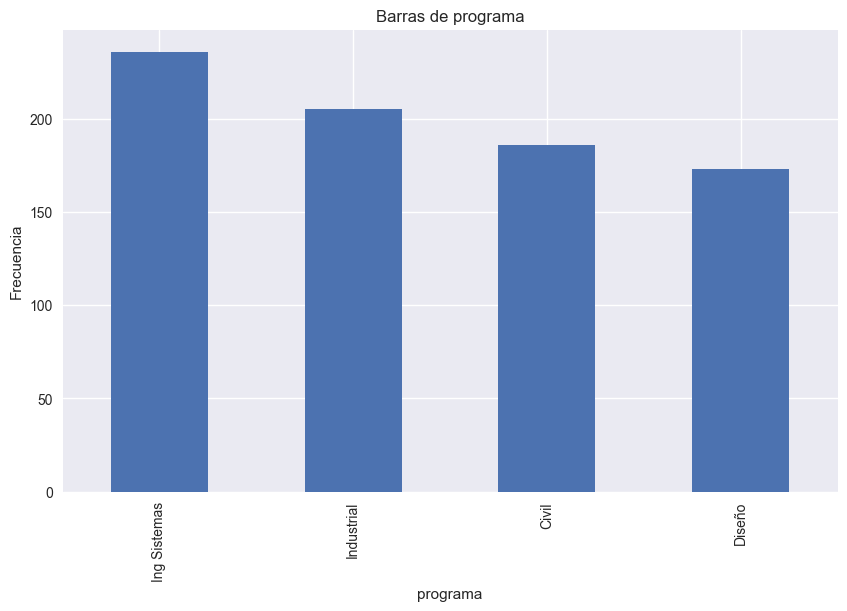

In [ ]:
def barras(df, col, top=None, titulo=None):
    """Grafica barras de una variable cualitativa."""
    if col not in df.columns:
        raise ValueError(f"La columna '{col}' no existe en el DataFrame.")

    vc = df[col].value_counts(dropna=False)
    if top is not None:
        vc = vc.head(top)

    plt.figure()
    vc.plot(kind="bar")
    plt.title(titulo if titulo else f"Barras de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Ejemplo
if "programa" in df.columns:
    barras(df, "programa")
else:
    print("ℹ️ Prueba con una columna cualitativa de tu dataset.")


In [ ]:
def crear_graficos_frecuencia(variable, titulo, tipo='bar'):
    """
    Crea gráficos de frecuencia para variables categóricas.

    Parameters:
        variable (pd.Series): Variable a graficar
        titulo (str): Título del gráfico
        tipo (str): Tipo de gráfico ('bar', 'pie')
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras
    freq = variable.value_counts()
    freq.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
    ax1.set_title(f'{titulo} - Frecuencias Absolutas')
    ax1.set_xlabel('Categorías')
    ax1.set_ylabel('Frecuencia')
    ax1.tick_params(axis='x', rotation=45)

    # Agregar valores en las barras
    for i, v in enumerate(freq.values):
        ax1.text(i, v + 0.5, str(v), ha='center')

    # Gráfico de pastel
    freq.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90,
              colors=['skyblue', 'lightcoral'])
    ax2.set_title(f'{titulo} - Distribución Porcentual')
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()

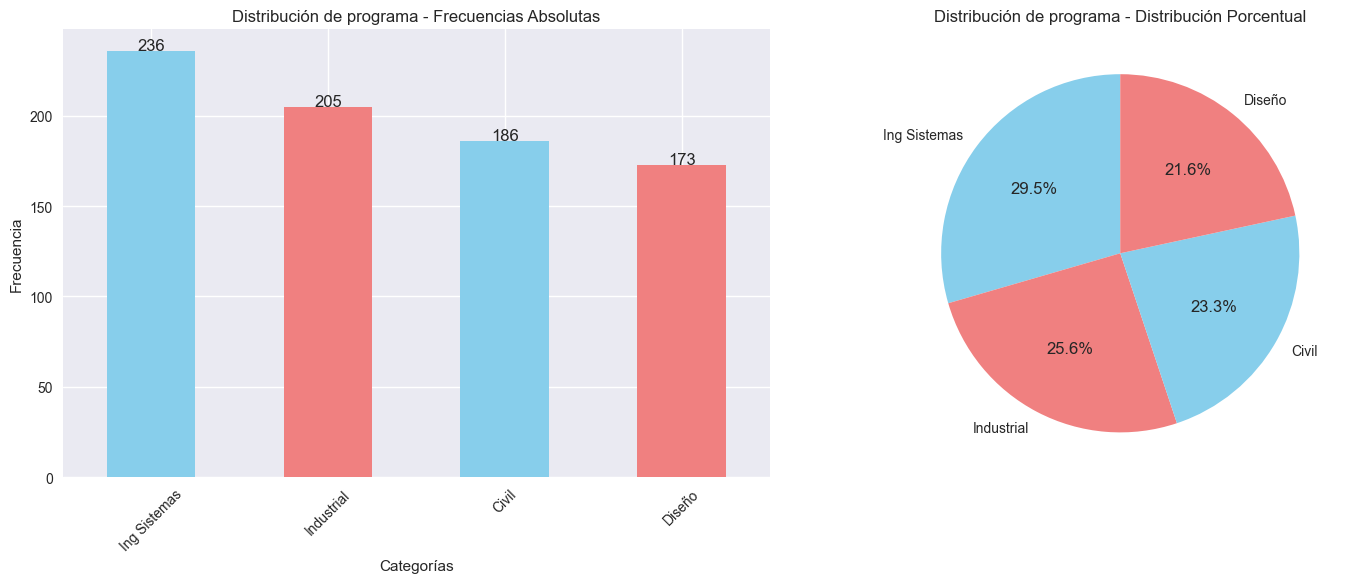

In [ ]:
# Crear gráficos para bajo peso
crear_graficos_frecuencia(df['programa'], 'Distribución de programa')

In [ ]:
def boxplot_comparativo(data, variable_numerica, variable_categorica, titulo):
    """
    Crea un boxplot comparativo entre grupos.

    Parameters:
        data (pd.DataFrame): Dataset
        variable_numerica (str): Variable numérica a comparar
        variable_categorica (str): Variable categórica para agrupar
        titulo (str): Título del gráfico
    """

    plt.figure(figsize=(10, 6))

    # Crear boxplot
    sns.boxplot(data=data, x=variable_categorica, y=variable_numerica,
                palette=['lightblue', 'lightcoral'])

    plt.title(titulo)
    plt.xlabel(variable_categorica.replace('_', ' ').title())
    plt.ylabel(variable_numerica.replace('_', ' ').title())

    # Agregar estadísticas en el gráfico
    for i, categoria in enumerate(data[variable_categorica].unique()):
        subset = data[data[variable_categorica] == categoria][variable_numerica]
        media = subset.mean()
        plt.text(i, media, f'Media: {media:.0f}',
                ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

C:\Users\1130590314\AppData\Local\Temp\ipykernel_43324\750492633.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=variable_categorica, y=variable_numerica,


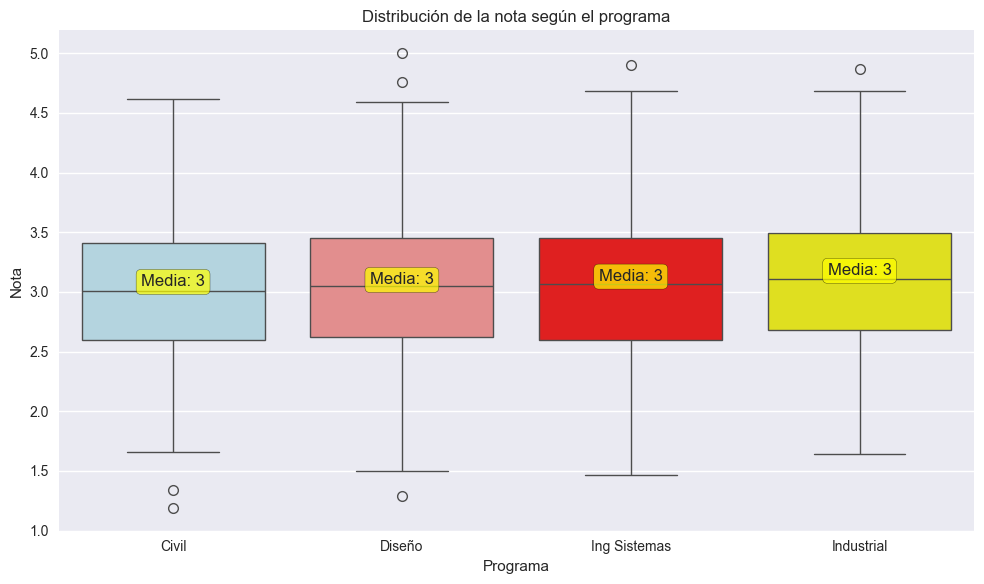

In [ ]:
boxplot_comparativo(df, 'nota', 'programa',
                   'Distribución de la nota según el programa')

## 11) Exportar resultados (para evidencias del taller)

In [ ]:
# Guardar un Excel con una hoja de datos y otra de resumen
output_file = "salida_taller.xlsx"

resumen_num = df.describe().T
nulos = df.isna().sum().to_frame("nulos")

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="datos", index=False)
    resumen_num.to_excel(writer, sheet_name="resumen_numerico")
    nulos.to_excel(writer, sheet_name="nulos")

print("✅ Archivo exportado:", output_file)


# Taller Entregable

Las autoridades de salud de la ciudad están preocupadas porque en cierta zona de esta se viene presentado un problema de salud en niños recién nacidos y consideran que el problema se debe a los malos hábitos de vida de las madres. Desarrollan un estudio a todas las madres que durante un periodo de seis meses dieron a luz un bebe en dicha zona. En este estudio se evaluaron aspectos de la historia clínica y sus hábitos de vida. La información de cada una de las madres y su hijo quedó registrada en la siguiente tabla.

**Id:** número identificador de la madre.

**Bajo_peso:** indica si él recién nacido tuvo bajo paso al momento de nacer (1=Si; 0=No).

**Edad:** edad de la madre en años cumplidos.

**Peso_madre:** peso de la madre en libras.

**Raza:** raza de la madre.

**Fumar:** antecedente de consumo de cigarrillo de la madre (1=Si; 0=No).

**TPP:** antecedente materno del número partos prematuros antes de este embarazo.

**Ant_HTA:** antecedente materno de hipertensión arterial (1=Si; 0=No).

**Irrit_uterina:** antecedente en este embarazo de irritabilidad uterina (1=Si; 0=No).

**Visitas_md:** número de visitas de control médico en este embarazo.

**peso_nacer:** peso real al nacer en gramos del recién nacido

**Notas importantes:**
- **Grupos de 3 personas**
- **Una persona del equipo sube la tarea**
**
- **Abra un espacio debajo de cada ítem para colocar su respuesta. La respuesta valida a cada ítem es la que se encuentre debajo de este.**
- **En los puntos 3 a 11 el resultado del procedimiento estadístico vale 50% y 50% la interpretación.**
- **Si realiza gráficos adicionales, se dará puntos adicionales en la nota (siempre y cuando aporten valor al analisis)**




Ayúdele al grupo de investigación a desarrollar el análisis estadístico de las siguientes preguntas:

1. Identifique cuáles variables son cualitativas y cuales son cuantitativas.



2. Clasifique cada una de las variables como nominal, ordinal, discreta o continua.


3. Construya la distribución de frecuencias para el bajo peso al nacer. ¿Existe realmente el problema?


4. Construya la distribución de frecuencias de la raza de la madre con el bajo peso. ¿Existe alguna relación?


5. Calcular las estadísticas descriptivas del peso al nacer por cada raza de la madre. Compare los resultados.


6. Construya la distribución de frecuencias de hábito de fumar por cada bajo peso. ¿Es un indicador del problema?


7. Construya la distribución de frecuencias de Hipertensión por cada bajo peso. ¿Es un indicador del problema?


8. Calcular las estadísticas descriptivas del número de visitas al médico por cada bajo peso. Compare los resultados.


9. Calcular las estadísticas descriptivas del peso de la madre por cada bajo peso. Compare los resultados.


10. Construya un gráfico de caja y bigotes para el peso de la madre por cada bajo peso.


11. Calcular las estadísticas descriptivas del peso al nacer por hábito de fumar de la madre. Compare los resultados.


12. Desarrolle una conclusión general del estudio con base en los resultados obtenidos.